In [13]:
# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed')

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('SMOTE (imbalanced-learn) available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not installed')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available')
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed')

print('\n All libraries loaded!')

XGBoost available
SMOTE (imbalanced-learn) available
SHAP available

 All libraries loaded!


In [14]:
# ─── 2. GENERATE REALISTIC HR DATA ───────────────────────────────────────────
# KEY IMPROVEMENT: More features, larger dataset

np.random.seed(42)
random.seed(42)

NUM_EMPLOYEES = 500
NUM_EDGES     = 2000
employee_ids  = list(range(1, NUM_EMPLOYEES + 1))

hr_data = pd.DataFrame({
    'Emp_ID':             employee_ids,
    'Region':             np.random.choice(['London', 'Manchester', 'Birmingham', 'Edinburgh'], NUM_EMPLOYEES),
    'Work_Model':         np.random.choice(['Remote', 'Hybrid', 'Office'], NUM_EMPLOYEES),
    'Tenure_Years':       np.random.randint(1, 16, NUM_EMPLOYEES),
    'Past_KPI_Score':     np.random.randint(40, 101, NUM_EMPLOYEES),
    # --- NEW features ---
    'Training_Hours':     np.random.randint(20, 201, NUM_EMPLOYEES),
    'Projects_Completed': np.random.randint(1, 21, NUM_EMPLOYEES),
    'Absence_Days':       np.random.randint(0, 25, NUM_EMPLOYEES),
    'Team_Size':          np.random.randint(2, 16, NUM_EMPLOYEES),
})

# Build communication network
communications = []
for _ in range(NUM_EDGES):
    sender   = random.choice(employee_ids)
    receiver = random.choice(employee_ids)
    if sender != receiver:
        weight = random.randint(1, 50)
        communications.append({'Sender': sender, 'Receiver': receiver, 'Weight': weight})
comm_df = pd.DataFrame(communications)

print(f'Generated {NUM_EMPLOYEES} employees | {len(comm_df)} communication edges')
hr_data.head()

Generated 500 employees | 1997 communication edges


,Emp_ID,Region,Work_Model,Tenure_Years,Past_KPI_Score,Training_Hours,Projects_Completed,Absence_Days,Team_Size
0,1,Birmingham,Office,10,63,22,15,20,6
1,2,Edinburgh,Remote,1,72,139,15,15,13
2,3,London,Remote,12,88,25,2,1,9
3,4,Birmingham,Office,4,68,24,1,10,11
4,5,Birmingham,Remote,8,82,24,11,9,15


In [15]:
# ─── 3. SOCIAL NETWORK ANALYSIS — 7 METRICS (up from 3) ──────────────────────
print('🕸️  Building network and computing SNA features...')

G = nx.from_pandas_edgelist(comm_df, source='Sender', target='Receiver',
                             edge_attr='Weight', create_using=nx.Graph())
G.add_nodes_from(employee_ids)  # include isolated nodes

print(f'   Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}')

degree_cen      = nx.degree_centrality(G)
betweenness_cen = nx.betweenness_centrality(G, normalized=True)
closeness_cen   = nx.closeness_centrality(G)
pagerank        = nx.pagerank(G, alpha=0.85, weight='Weight')       # NEW
eigenvector_cen = nx.eigenvector_centrality(G, max_iter=500)        # NEW
clustering      = nx.clustering(G)                                   # NEW
weighted_degree = {n: sum(d.get('Weight', 1) for _, _, d in G.edges(n, data=True))
                   for n in G.nodes()}                               # NEW

sna_df = pd.DataFrame({
    'Emp_ID':                 list(degree_cen.keys()),
    'Degree_Centrality':      list(degree_cen.values()),
    'Betweenness_Centrality': list(betweenness_cen.values()),
    'Closeness_Centrality':   list(closeness_cen.values()),
    'PageRank':               [pagerank[n]        for n in degree_cen],
    'Eigenvector_Centrality': [eigenvector_cen[n] for n in degree_cen],
    'Clustering_Coefficient': [clustering[n]      for n in degree_cen],
    'Weighted_Degree':        [weighted_degree[n] for n in degree_cen],
})

full_data = pd.merge(hr_data, sna_df, on='Emp_ID', how='left').fillna(0)
print(f'SNA done. Shape: {full_data.shape}')

🕸️  Building network and computing SNA features...
   Nodes: 500 | Edges: 1980
SNA done. Shape: (500, 16)


In [4]:
# ─── 4. CREATE REALISTIC CORRELATED LABELS ────────────────────────────────────
# THE KEY FIX: labels are driven by features, not random assignment!
# v1 used np.random.choice([0,1]) → 50% accuracy (model learns nothing)
# v2 uses a weighted performance score → model can actually learn

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Normalise to [0, 1]
kpi_n      = (full_data['Past_KPI_Score'] - 40) / 60
tenure_n   = (full_data['Tenure_Years'] - 1) / 14
degree_n   = full_data['Degree_Centrality'] / (full_data['Degree_Centrality'].max() + 1e-9)
training_n = (full_data['Training_Hours'] - 20) / 180
projects_n = (full_data['Projects_Completed'] - 1) / 19
absence_n  = full_data['Absence_Days'] / 24
pagerank_n = full_data['PageRank'] / (full_data['PageRank'].max() + 1e-9)

# Weighted performance score (absence penalises)
perf = (0.35*kpi_n + 0.20*projects_n + 0.15*training_n +
        0.15*degree_n + 0.10*pagerank_n + 0.10*tenure_n - 0.15*absence_n)

noise = np.random.normal(0, 0.12, NUM_EMPLOYEES)
prob  = sigmoid((perf + noise - perf.mean()) * 5)
full_data['High_Performer'] = (prob > 0.55).astype(int)

pct = full_data['High_Performer'].mean() * 100
print(f' Labels created — High Performers: {pct:.1f}%  |  Average: {100-pct:.1f}%')

# Show correlations to confirm labels are meaningful
print('\nFeature correlations with High_Performer:')
corr_cols = ['Past_KPI_Score','Projects_Completed','Training_Hours',
             'Absence_Days','Degree_Centrality','PageRank','Tenure_Years']
print(full_data[corr_cols + ['High_Performer']].corr()['High_Performer']
      .drop('High_Performer').sort_values(ascending=False).round(3).to_string())

✅ Labels created — High Performers: 40.2%  |  Average: 59.8%

Feature correlations with High_Performer:
Past_KPI_Score        0.443
Projects_Completed    0.259
Training_Hours        0.190
PageRank              0.181
Degree_Centrality     0.174
Tenure_Years          0.141
Absence_Days         -0.183


In [5]:
# ─── 5. FEATURE ENGINEERING ───────────────────────────────────────────────────
feat = full_data.copy()

feat['KPI_Tenure_Score']   = feat['Past_KPI_Score'] * np.log1p(feat['Tenure_Years'])
feat['Network_Influence']  = feat['Degree_Centrality'] * feat['Betweenness_Centrality']
feat['Productivity']       = feat['Projects_Completed'] / (feat['Training_Hours'] / 40).clip(lower=0.1)
feat['Reliability']        = 1 - (feat['Absence_Days'] / 30)
feat['Connectedness']      = feat['PageRank'] * feat['Eigenvector_Centrality']

print(f' Feature engineering done — {feat.shape[1]} total columns')

✅ Feature engineering done — 22 total columns


In [6]:
# ─── 6. PREPARE TRAINING DATA ─────────────────────────────────────────────────
model_data  = pd.get_dummies(feat, columns=['Region', 'Work_Model'], drop_first=False)
feature_cols = [c for c in model_data.columns if c not in ['Emp_ID', 'High_Performer']]
X = model_data[feature_cols]
y = model_data['High_Performer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler         = StandardScaler()
X_train_sc     = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc      = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_tr, y_tr = sm.fit_resample(X_train_sc, y_train)
    print(f'SMOTE applied — {X_tr.shape[0]} balanced training samples')
else:
    X_tr, y_tr = X_train_sc, y_train
    print('SMOTE unavailable — using class_weight="balanced"')

print(f'Train: {X_tr.shape}  |  Test: {X_test.shape}')

✅ SMOTE applied — 478 balanced training samples
Train: (478, 25)  |  Test: (100, 25)


In [7]:
# ─── 7. TRAIN & COMPARE 4 MODELS ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}
if XGBOOST_AVAILABLE:
    pos_w = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models['XGBoost'] = XGBClassifier(scale_pos_weight=pos_w, n_estimators=200,
                                       random_state=42, eval_metric='logloss', verbosity=0)

results = {}
print('Training models...\n')
for name, model in models.items():
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1').mean()
    model.fit(X_tr, y_tr)
    yp  = model.predict(X_test_sc)
    ypr = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        'model': model, 'y_pred': yp, 'y_proba': ypr,
        'accuracy':  accuracy_score(y_test, yp),
        'f1':        f1_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall':    recall_score(y_test, yp),
        'roc_auc':   roc_auc_score(y_test, ypr),
        'cv_f1':     cv_f1,
    }
    r = results[name]
    print(f'  {name:22s}  Acc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}  '
          f'ROC-AUC={r["roc_auc"]:.3f}  CV-F1={cv_f1:.3f}')

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\n Best model: {best_name} (ROC-AUC={results[best_name]["roc_auc"]:.3f})')

Training models...

  Logistic Regression     Acc=0.790  F1=0.753  ROC-AUC=0.919  CV-F1=0.788
  Random Forest           Acc=0.790  F1=0.747  ROC-AUC=0.901  CV-F1=0.785
  Gradient Boosting       Acc=0.800  F1=0.756  ROC-AUC=0.920  CV-F1=0.770
  XGBoost                 Acc=0.780  F1=0.732  ROC-AUC=0.889  CV-F1=0.788

🏆 Best model: Gradient Boosting (ROC-AUC=0.920)


In [8]:
# ─── 8. HYPERPARAMETER TUNING — RANDOM FOREST ────────────────────────────────
print('🔧 GridSearchCV for Random Forest... (~60s)')

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}
gs = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                  param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
gs.fit(X_tr, y_tr)
best_rf   = gs.best_estimator_
yp_rf     = best_rf.predict(X_test_sc)
ypr_rf    = best_rf.predict_proba(X_test_sc)[:, 1]

results['Random Forest (Tuned)'] = {
    'model': best_rf, 'y_pred': yp_rf, 'y_proba': ypr_rf,
    'accuracy':  accuracy_score(y_test, yp_rf),
    'f1':        f1_score(y_test, yp_rf),
    'precision': precision_score(y_test, yp_rf),
    'recall':    recall_score(y_test, yp_rf),
    'roc_auc':   roc_auc_score(y_test, ypr_rf),
    'cv_f1':     gs.best_score_,
}
r = results['Random Forest (Tuned)']
print(f'\n Best params: {gs.best_params_}')
print(f'   Accuracy={r["accuracy"]:.3f}  F1={r["f1"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}')

🔧 GridSearchCV for Random Forest... (~60s)

✅ Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   Accuracy=0.820  F1=0.780  ROC-AUC=0.902


In [9]:
# ─── 9. MODEL COMPARISON TABLE ────────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Model': n, 'Accuracy': f"{v['accuracy']:.3f}", 'F1': f"{v['f1']:.3f}",
     'Precision': f"{v['precision']:.3f}", 'Recall': f"{v['recall']:.3f}",
     'ROC-AUC': f"{v['roc_auc']:.3f}", 'CV F1': f"{v['cv_f1']:.3f}"}
    for n, v in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('\n MODEL COMPARISON')
display(comparison)


📊 MODEL COMPARISON


,Model,Accuracy,F1,Precision,Recall,ROC-AUC,CV F1
0,Gradient Boosting,0.800,0.756,0.738,0.775,0.920,0.770
1,Logistic Regression,0.790,0.753,0.711,0.800,0.919,0.788
2,Random Forest (Tuned),0.820,0.780,0.762,0.800,0.902,0.810
3,Random Forest,0.790,0.747,0.721,0.775,0.901,0.785
4,XGBoost,0.780,0.732,0.714,0.750,0.889,0.788


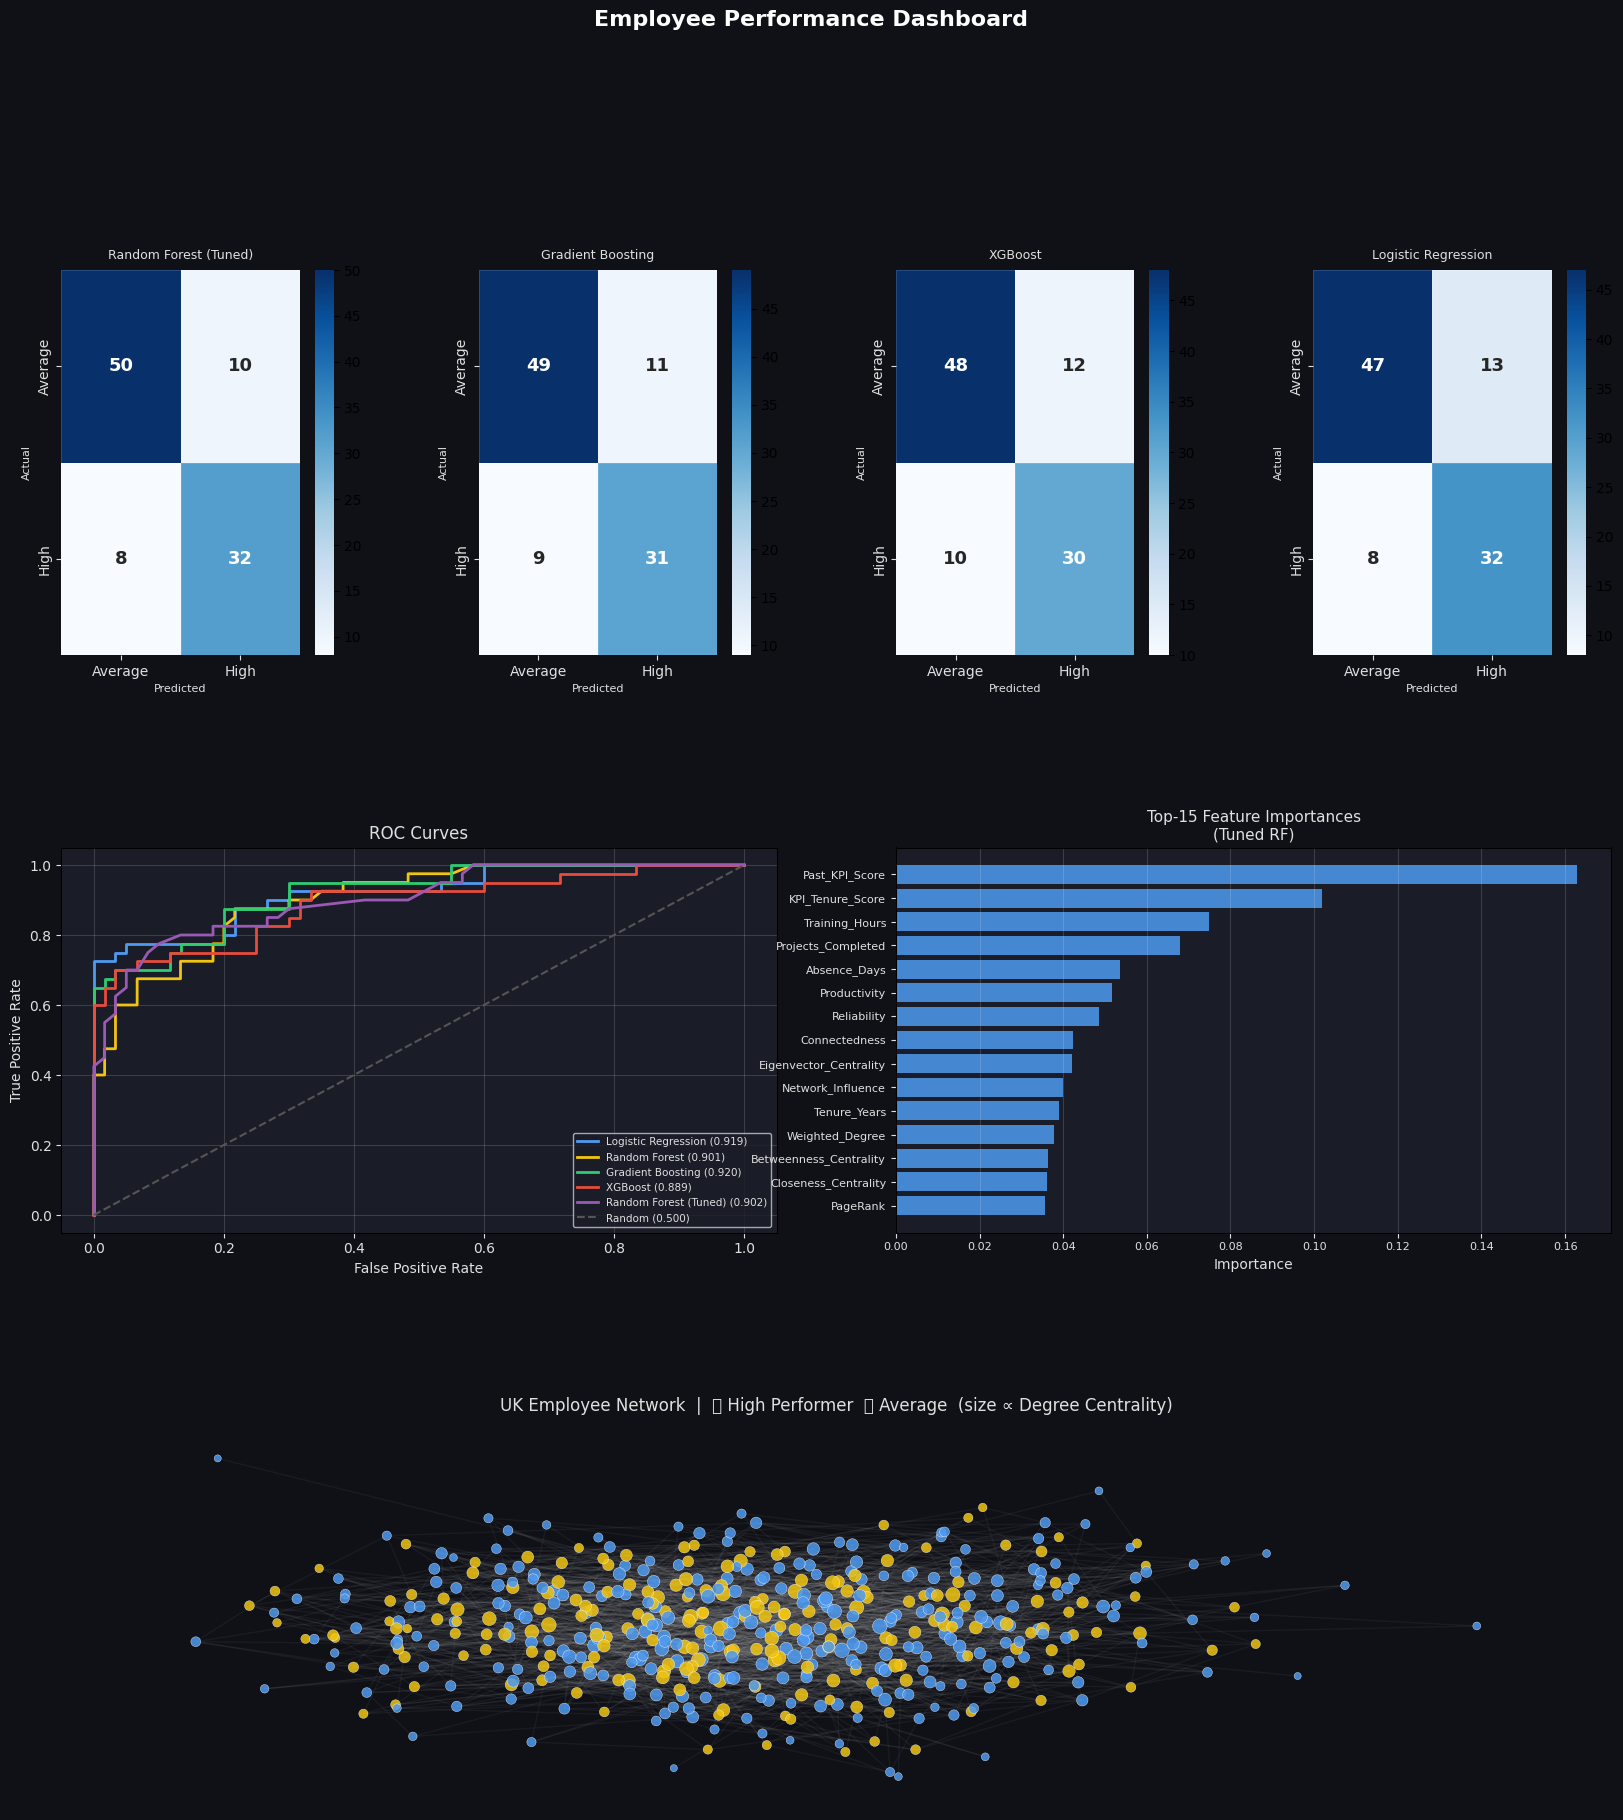

✅ Dashboard saved!


In [10]:
# ─── 10. DASHBOARD VISUALISATION ─────────────────────────────────────────────

DARK_BG  = '#1a1d27'
TEXT_COL = '#e0e0e0'
ACCENT   = '#4e9af1'

show_models = [m for m in ['Random Forest (Tuned)', 'Gradient Boosting',
                            'XGBoost', 'Logistic Regression'] if m in results]
n_mod = len(show_models)

fig = plt.figure(figsize=(max(16, 5*n_mod), 20))
fig.patch.set_facecolor('#0f1117')
gs2  = gridspec.GridSpec(3, n_mod, figure=fig, hspace=0.5, wspace=0.4)

# A — Confusion Matrices
for i, mname in enumerate(show_models):
    ax = fig.add_subplot(gs2[0, i])
    ax.set_facecolor(DARK_BG)
    cm = confusion_matrix(y_test, results[mname]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Average', 'High'], yticklabels=['Average', 'High'],
                annot_kws={'size': 13, 'weight': 'bold'},
                linewidths=0.5, linecolor='#ffffff22')
    ax.set_title(mname, color=TEXT_COL, fontsize=9, pad=8)
    ax.set_xlabel('Predicted', color=TEXT_COL, fontsize=8)
    ax.set_ylabel('Actual',    color=TEXT_COL, fontsize=8)
    ax.tick_params(colors=TEXT_COL)

# B — ROC Curves
ax_roc = fig.add_subplot(gs2[1, :n_mod//2])
ax_roc.set_facecolor(DARK_BG)
colors = ['#4e9af1', '#f1c40f', '#2ecc71', '#e74c3c', '#9b59b6']
for (mname, v), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax_roc.plot(fpr, tpr, label=f"{mname} ({v['roc_auc']:.3f})", color=col, lw=2)
ax_roc.plot([0,1],[0,1],'--',color='#555',lw=1.5,label='Random (0.500)')
ax_roc.set_title('ROC Curves', color=TEXT_COL, fontsize=12)
ax_roc.set_xlabel('False Positive Rate', color=TEXT_COL)
ax_roc.set_ylabel('True Positive Rate',  color=TEXT_COL)
ax_roc.tick_params(colors=TEXT_COL)
ax_roc.legend(fontsize=7.5, facecolor='#1a1d27', labelcolor=TEXT_COL, framealpha=0.8)
ax_roc.grid(alpha=0.15, color='white')

# C — Feature Importances
ax_fi = fig.add_subplot(gs2[1, n_mod//2:])
ax_fi.set_facecolor(DARK_BG)
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).nlargest(15).sort_values()
ax_fi.barh(importances.index, importances.values, color=ACCENT, alpha=0.85, edgecolor='none')
ax_fi.set_title('Top-15 Feature Importances\n(Tuned RF)', color=TEXT_COL, fontsize=11)
ax_fi.set_xlabel('Importance', color=TEXT_COL)
ax_fi.tick_params(colors=TEXT_COL, labelsize=8)
ax_fi.grid(axis='x', alpha=0.15, color='white')

# D — Network Graph
ax_net = fig.add_subplot(gs2[2, :])
ax_net.set_facecolor('#0a0c14')
pos    = nx.spring_layout(G, k=0.15, iterations=20, seed=42)
pm     = dict(zip(full_data['Emp_ID'], full_data['High_Performer']))
nc     = ['#f1c40f' if pm.get(n,0)==1 else '#4e9af1' for n in G.nodes()]
ns     = [degree_cen.get(n,0)*3000+20 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=ns, node_color=nc,
                       alpha=0.85, edgecolors='white', linewidths=0.3, ax=ax_net)
nx.draw_networkx_edges(G, pos, alpha=0.06, edge_color='#cccccc', ax=ax_net)
ax_net.set_title('UK Employee Network  |  🟡 High Performer  🔵 Average  (size ∝ Degree Centrality)',
                 color=TEXT_COL, fontsize=12, pad=10)
ax_net.axis('off')

plt.suptitle('Employee Performance Dashboard', color='white', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('performance_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Dashboard saved!')

🔍 Computing SHAP values...


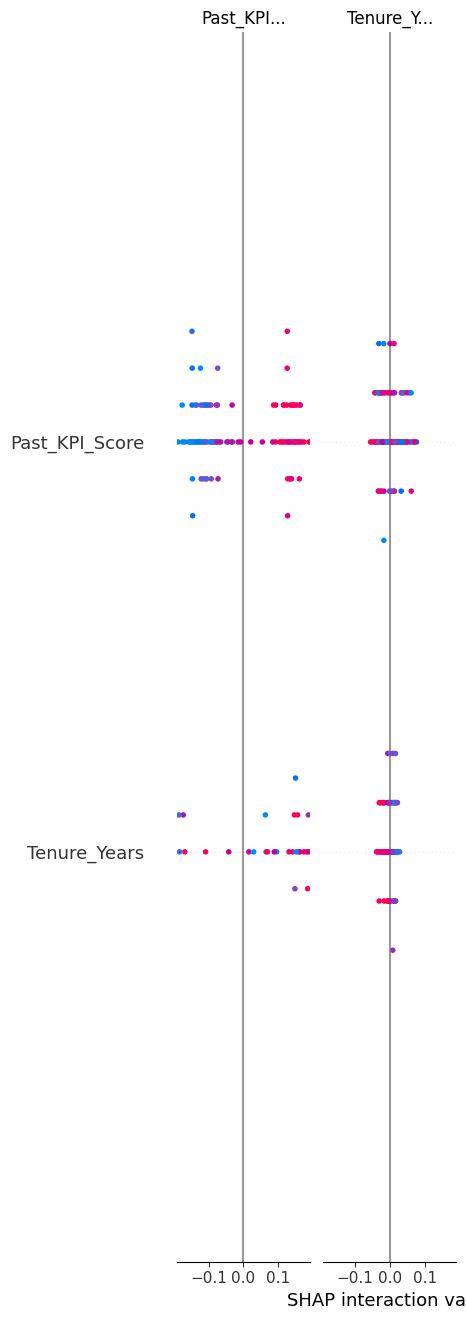

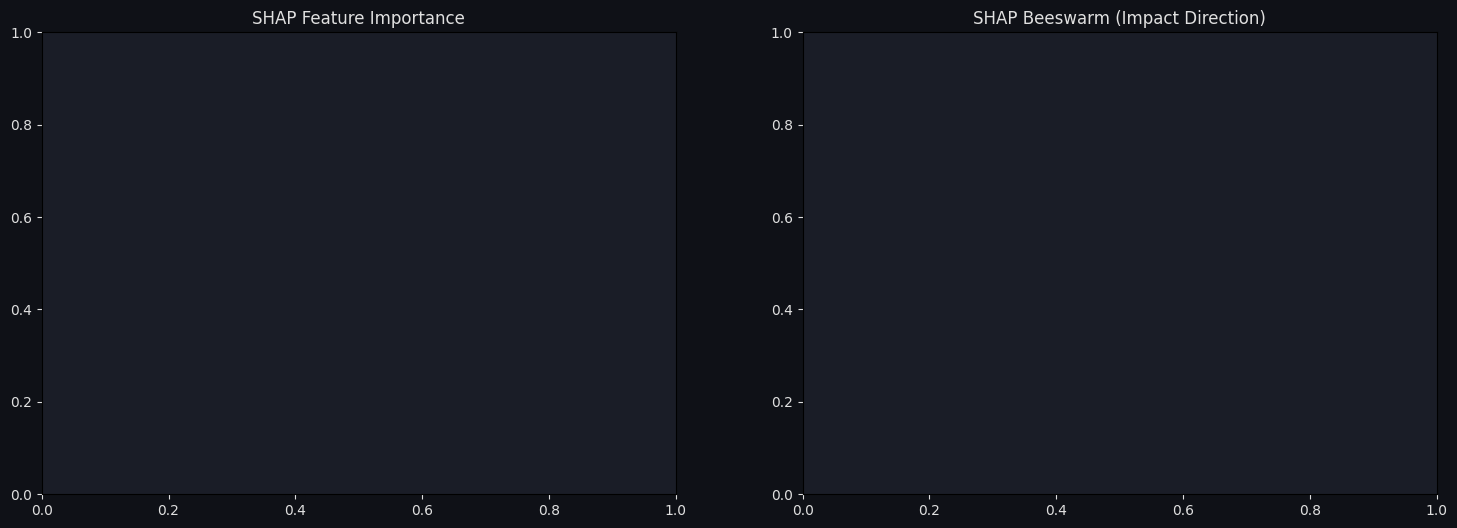

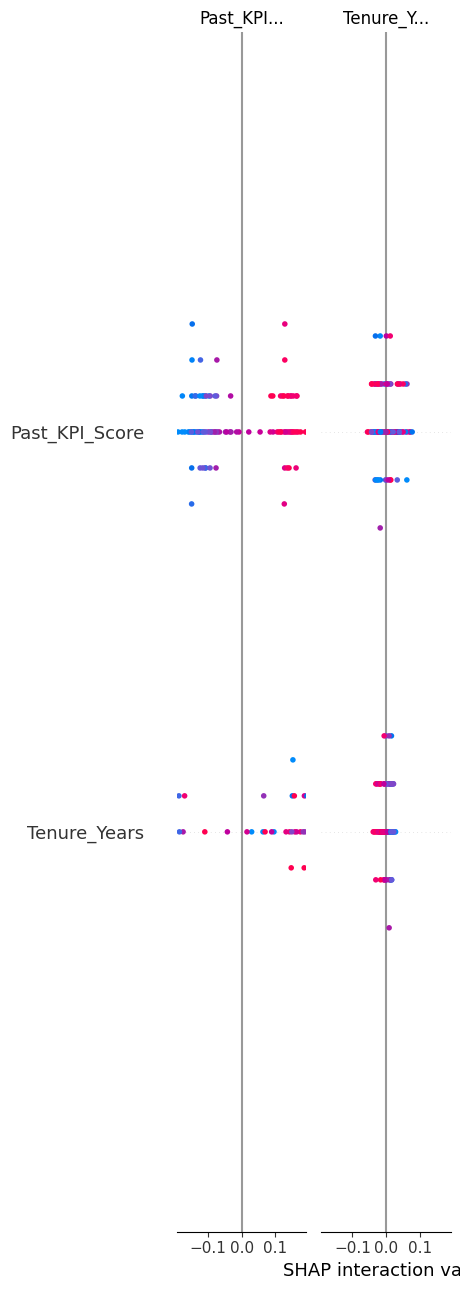

✅ SHAP plots saved!


In [11]:
# ─── 11. SHAP EXPLAINABILITY ──────────────────────────────────────────────────
if SHAP_AVAILABLE:
    print(' Computing SHAP values...')
    explainer   = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test_sc)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    fig_s, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig_s.patch.set_facecolor('#0f1117')

    plt.sca(axes[0])
    shap.summary_plot(sv, X_test_sc, plot_type='bar', show=False, color=ACCENT, max_display=15)
    axes[0].set_title('SHAP Feature Importance', color=TEXT_COL, fontsize=12)
    axes[0].set_facecolor(DARK_BG)
    axes[0].tick_params(colors=TEXT_COL)

    plt.sca(axes[1])
    shap.summary_plot(sv, X_test_sc, plot_type='dot', show=False, max_display=15)
    axes[1].set_title('SHAP Beeswarm (Impact Direction)', color=TEXT_COL, fontsize=12)
    axes[1].set_facecolor(DARK_BG)
    axes[1].tick_params(colors=TEXT_COL)

    plt.tight_layout()
    plt.savefig('shap_explainability.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print(' SHAP plots saved!')
else:
    print(' SHAP unavailable — install with: pip install shap')

In [12]:
# ─── 12. SAVE BEST MODEL ─────────────────────────────────────────────────────
import pickle

overall_best = max(results, key=lambda k: results[k]['roc_auc'])
payload = {
    'model':        results[overall_best]['model'],
    'model_name':   overall_best,
    'scaler':       scaler,
    'feature_cols': feature_cols,
    'metrics': {
        'accuracy': results[overall_best]['accuracy'],
        'f1':       results[overall_best]['f1'],
        'roc_auc':  results[overall_best]['roc_auc'],
    }
}
with open('employee_performance_model.pkl', 'wb') as f:
    pickle.dump(payload, f)

r = results[overall_best]
print(f' Best model saved: {overall_best}')
print(f'   Accuracy : {r["accuracy"]:.3f}')
print(f'   F1 Score : {r["f1"]:.3f}')
print(f'   ROC-AUC  : {r["roc_auc"]:.3f}')
print('\n All done!')

✅ Best model saved: Gradient Boosting
   Accuracy : 0.800
   F1 Score : 0.756
   ROC-AUC  : 0.920

🎉 All done!
